# 04 — Ensembling the two families

Notebook 01 built the reasoning ensemble. Notebook 03 showed that a
two-minute sklearn baseline beats it on VCBench and loses to it on Movie.
Neither family wins outright, which makes "which one is better" the wrong
question.

The right one is whether they are wrong about *different* founders and
different films. If they are, combining them is worth more than picking a
winner, and that holds whichever family happens to be ahead on your dataset.

That is what this notebook checks, and it is the example's actual claim:

> **The combined ensemble beats both families, on both metrics, on both
> reproducible splits.**

Everything below is computed from `precomputed/`. No network, no Ollama, no raw
data.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import average_precision_score, roc_auc_score


def find_example_root(start: Path | None = None) -> Path:
    """Walk up from `start` (default: the CWD) to the example dir holding precomputed/."""
    start = (start or Path.cwd()).resolve()
    for parent in (start, *start.parents):
        for candidate in (parent, parent / "examples" / "vcbench-movie-local"):
            if (candidate / "precomputed").is_dir():
                return candidate
    raise FileNotFoundError(
        "Could not find the example directory (the one containing precomputed/) "
        f"above {start}. Run this notebook from inside the example."
    )


EXAMPLE_ROOT = find_example_root()
PRECOMPUTED = EXAMPLE_ROOT / "precomputed"

METHODS = {"PI": "pi", "RRF": "rrf", "GPTree": "gptree", "RRM": "rrm"}
SPLITS = {"VCBench public": "vcbench_public", "Movie test": "movie_test"}

REASONING, TRADITIONAL, COMBINED = "Reasoning ensemble", "Traditional ensemble", "Combined"


def score_ranking(labels, scores) -> dict[str, float]:
    return {
        "ROC-AUC": roc_auc_score(labels, scores),
        "PR-AUC": average_precision_score(labels, scores),
    }


def load_scores(prefix: str, series: str) -> pd.DataFrame:
    """`id` is the founder_uuid on VCBench and the IMDb tconst on Movie."""
    return pd.read_csv(PRECOMPUTED / f"{prefix}_{series}_scores.csv").set_index("id")


# Only the traditional file carries a label on both splits: the reasoning files
# for a held-out split ship scores alone, so the label comes from there.
labels = {name: load_scores(prefix, "traditional")["label"] for name, prefix in SPLITS.items()}

for name, y in labels.items():
    print(f"{name}: n={len(y):,} · base rate {y.mean():.3f}")

VCBench public: n=4,500 · base rate 0.090
Movie test: n=727 · base rate 0.208


## Step 1 — the reasoning ensemble

Same operator as notebook 01. Convert each method's scores to percentile ranks
within the split, then average the four ranks per row.

One detail that matters more than it looks. `rank(pct=True)` uses pandas'
default tie handling, `method="average"`, and GPTree's scores are heavily tied
because a decision tree only emits one value per leaf. Switching to
`method="dense"` moves the VCBench ensemble from 0.7188 to 0.7244, which looks
like an improvement and is really just a different convention for splitting
ties. Pick one, use it everywhere, and say which.

In [2]:
def reasoning_ensemble(prefix: str, index: pd.Index) -> pd.Series:
    wide = pd.DataFrame(
        {name: load_scores(prefix, key)["score"] for name, key in METHODS.items()}
    ).reindex(index)
    return wide.rank(pct=True).mean(axis=1)  # method="average" is the default


reasoning = {name: reasoning_ensemble(prefix, labels[name].index) for name, prefix in SPLITS.items()}

for name, scores in reasoning.items():
    metrics = score_ranking(labels[name], scores)
    print(f"{name} · reasoning ensemble · ROC-AUC {metrics['ROC-AUC']:.4f} · "
          f"PR-AUC {metrics['PR-AUC']:.4f}")

VCBench public · reasoning ensemble · ROC-AUC 0.7188 · PR-AUC 0.2072
Movie test · reasoning ensemble · ROC-AUC 0.6515 · PR-AUC 0.3007


## Step 2 — the combined ensemble

The traditional ensemble is already a rank-average, of five sklearn models
rather than four LLM methods, and its score column ships in
`precomputed/*_traditional_scores.csv`.

To combine the two, rank each family's final score to [0, 1] and add them:

```python
combined = rank01(traditional) + rank01(reasoning)
```

Two families, one weight each. Not a mean over all nine models: that would give
the traditional side five votes to the reasoning side's four, and the question
here is what the two *families* add to each other, not what happens when you
pour every model into one bucket. Re-ranking the reasoning ensemble before
adding also stops its already-averaged ranks, which bunch toward the middle,
from carrying less weight than the traditional column's fuller spread.

There is no fitting involved. Nothing is tuned on the labels, so there is
nothing here that can overfit the split it is being evaluated on.

In [3]:
def rank01(scores: pd.Series) -> pd.Series:
    return scores.rank(pct=True)


def build_results(name: str, prefix: str) -> pd.DataFrame:
    y = labels[name]
    traditional = load_scores(prefix, "traditional")["score"].reindex(y.index)
    series = {method: load_scores(prefix, key)["score"].reindex(y.index)
              for method, key in METHODS.items()}
    series[REASONING] = reasoning[name]
    series[TRADITIONAL] = traditional
    series[COMBINED] = rank01(traditional) + rank01(reasoning[name])
    table = pd.DataFrame({label: score_ranking(y, s) for label, s in series.items()}).T
    table.index.name = name
    return table


results = {name: build_results(name, prefix) for name, prefix in SPLITS.items()}

for name, table in results.items():
    print(f"\n{name}")
    display(table.round(4))


VCBench public


,ROC-AUC,PR-AUC
VCBench public,,
PI,0.6763,0.1831
RRF,0.6604,0.1689
GPTree,0.6161,0.1320
RRM,0.6665,0.1725
Reasoning ensemble,0.7188,0.2072
Traditional ensemble,0.7382,0.2258
Combined,0.7610,0.2546



Movie test


,ROC-AUC,PR-AUC
Movie test,,
PI,0.6346,0.2761
RRF,0.6406,0.3048
GPTree,0.5728,0.2447
RRM,0.5787,0.2465
Reasoning ensemble,0.6515,0.3007
Traditional ensemble,0.6354,0.2927
Combined,0.6704,0.3166


In [4]:
# The full board, checked against the reference run. Any drift in a load, a
# join or a rank convention fails here rather than printing new numbers.
REFERENCE = {
    "VCBench public": {
        "PI": (0.6763, 0.1831), "RRF": (0.6604, 0.1689),
        "GPTree": (0.6161, 0.1320), "RRM": (0.6665, 0.1725),
        REASONING: (0.7188, 0.2072), TRADITIONAL: (0.7382, 0.2258),
        COMBINED: (0.7610, 0.2546),
    },
    "Movie test": {
        "PI": (0.6346, 0.2761), "RRF": (0.6406, 0.3048),
        "GPTree": (0.5728, 0.2447), "RRM": (0.5787, 0.2465),
        REASONING: (0.6515, 0.3007), TRADITIONAL: (0.6354, 0.2927),
        COMBINED: (0.6704, 0.3166),
    },
}
for split, expected in REFERENCE.items():
    for series, (roc, pr) in expected.items():
        row = results[split].loc[series]
        assert abs(row["ROC-AUC"] - roc) < 1e-3, (split, series, "ROC-AUC", row["ROC-AUC"], roc)
        assert abs(row["PR-AUC"] - pr) < 1e-3, (split, series, "PR-AUC", row["PR-AUC"], pr)

print(f"All {sum(len(v) for v in REFERENCE.values())} series match the reference run "
      f"to within 0.001 on both metrics.")

margins = pd.DataFrame({
    split: {
        f"{metric} vs traditional": table.loc[COMBINED, metric] - table.loc[TRADITIONAL, metric]
        for metric in ("ROC-AUC", "PR-AUC")
    } | {
        f"{metric} vs reasoning": table.loc[COMBINED, metric] - table.loc[REASONING, metric]
        for metric in ("ROC-AUC", "PR-AUC")
    }
    for split, table in results.items()
})
print("\nWhat combining buys, over each family alone:")
margins.round(4)

All 14 series match the reference run to within 0.001 on both metrics.

What combining buys, over each family alone:


,VCBench public,Movie test
ROC-AUC vs traditional,0.0228,0.0350
PR-AUC vs traditional,0.0288,0.0239
ROC-AUC vs reasoning,0.0422,0.0189
PR-AUC vs reasoning,0.0474,0.0159


## The picture

Three series per panel, both metrics, both datasets. The dashed line is chance:
0.5 for ROC-AUC, the split's base rate for PR-AUC, which is why the PR panels
look low on VCBench and are in fact the more impressive half.

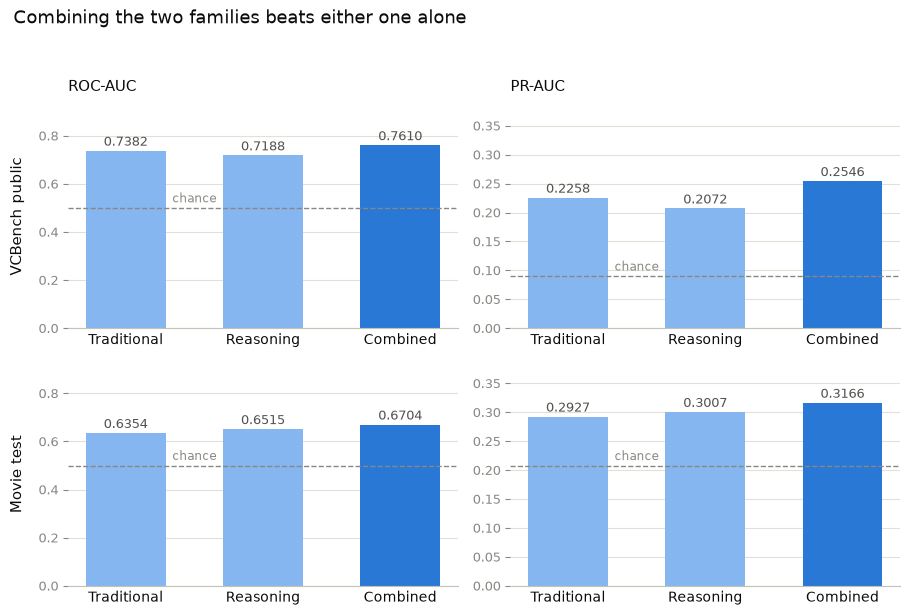

In [5]:
PEER, HIGHLIGHT = "#86b6ef", "#2a78d6"
GRID, AXIS, TICK, VALUE, TITLE = "#e1e0d9", "#c3c2b7", "#898781", "#52514e", "#0b0b0b"

order = [TRADITIONAL, REASONING, COMBINED]
short = ["Traditional", "Reasoning", "Combined"]
colors = [HIGHLIGHT if s == COMBINED else PEER for s in order]

METRICS = ("ROC-AUC", "PR-AUC")
# One y scale per metric so the two datasets can be read against each other.
tops = {metric: max(max(t.loc[order, metric].max() for t in results.values()),
                    0.5 if metric == "ROC-AUC" else max(y.mean() for y in labels.values())) * 1.22
        for metric in METRICS}

fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.2), sharey="col")

for row, (split, table) in enumerate(results.items()):
    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        top = tops[metric]
        values = table.loc[order, metric]
        bars = ax.bar(short, values, color=colors, width=0.58)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value + top * 0.022, f"{value:.4f}",
                    ha="center", fontsize=9.5, color=VALUE)

        chance = 0.5 if metric == "ROC-AUC" else labels[split].mean()
        ax.axhline(chance, color=TICK, linewidth=1, linestyle="--")
        ax.text(0.5, chance + top * 0.012, "chance", fontsize=8.5, color=TICK,
                va="bottom", ha="center")

        ax.set_ylim(0, top)
        if row == 0:
            ax.set_title(metric, color=TITLE, fontsize=11, loc="left", pad=10)
        if col == 0:
            ax.set_ylabel(split, color=TITLE, fontsize=10.5, labelpad=10)
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", colors=TICK, labelsize=9)
        ax.tick_params(axis="x", colors=TITLE, length=0, labelsize=10)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)

fig.suptitle("Combining the two families beats either one alone",
             color=TITLE, fontsize=13, x=0.02, ha="left", y=0.985)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## What this does and does not show

**It shows** that on both reproducible splits, the combined ensemble beats both
families on both metrics. On VCBench the margin is clear: +0.023 ROC-AUC and
+0.029 PR-AUC over the traditional ensemble, which was itself the best thing in
notebook 03, and +0.042 / +0.047 over the reasoning ensemble. On Movie it is
+0.035 / +0.024 over traditional and +0.019 / +0.016 over reasoning, on 727
films, which is thin enough to want more data before leaning on it.

**It does not show** that reasoning methods beat traditional ML. On VCBench they
lose, on Movie they win by less than the noise, and one of the two orderings
would have been reversed if the example had shipped only one dataset. Any claim
of the form "reasoning wins" is a claim about a dataset, not about the methods.

The result that survives both datasets is the weaker and more useful one: the
two families make different mistakes, and rank-averaging them is a free way to
collect both. Free in the sense that it fits nothing and cannot overfit, not in
the sense that it is cheap: you still paid for both families to run.

**And ensembling is not a guarantee.** Notebook 02's private-split table has the
counterexample. The reasoning ensemble beats all four of its members on public
ROC-AUC, public PR-AUC and private ROC-AUC, but on private PR-AUC RRF alone
scores 0.2262 against the ensemble's 0.2129. Averaging is a good default under
uncertainty about which method will hold up. It is not a proof that the average
is best.

## The private split

VCBench keeps a second 4,500-founder split whose labels are not in this repo.
It is the number to beat, and it is the honest test of everything above, since
nothing here was tuned on it.

The table below is a static reference from the maintainers' run, not a
computation: without labels these metrics cannot be recomputed here, which is
the point of holding them back. The traditional suite's own private reference
from the same run is about 0.742 ROC-AUC / 0.257 PR-AUC, from a train-on-public,
test-on-private fit rather than the 3-fold protocol behind the 0.7382 above, so
read it as a neighbouring number and not a directly comparable one.

**There is no private combined number, here or anywhere.** The private prose is
not shipped, and by the same hygiene rule that keeps the labels out, these
notebooks do not touch the private split at all. Computing one is a maintainer
job on data this example never sees.

In [6]:
# Static reference. Not computed: VCBench's private labels are not in this repo.
private = pd.DataFrame(
    [
        ("PI", 0.6556, 0.1740),
        ("RRF", 0.6681, 0.2262),
        ("GPTree", 0.5268, 0.1053),
        ("RRM", 0.6662, 0.1638),
        (REASONING, 0.6850, 0.2129),
    ],
    columns=["Series", "ROC-AUC", "PR-AUC"],
).set_index("Series")
private.index.name = "VCBench private (static)"

private

,ROC-AUC,PR-AUC
VCBench private (static),,
PI,0.6556,0.1740
RRF,0.6681,0.2262
GPTree,0.5268,0.1053
RRM,0.6662,0.1638
Reasoning ensemble,0.6850,0.2129


## Where next

That is the example. Four reasoning methods, a traditional baseline, and the
combination that beats both.

To run any of it yourself rather than reading the shipped scores:

- `scripts/run_pi.py`, `run_rrf.py`, `run_gptree.py`, `run_rrm.py` run one
  reasoning method end to end against a local Ollama model. Hours, not minutes.
- `scripts/run_traditional.py` runs the sklearn suite. Minutes, not hours.
- The example README covers getting the data and the runtime you should expect
  on your own hardware.